# My Individual Models: Image Captioning

This notebook implements and evaluates two image captioning architectures for my individual component:

- Model 1: ResNet50 encoder + LSTM decoder
- Model 2: ResNet50 encoder + LSTM decoder + attention mechanism

Both models use the shared Phase 1 VizWiz data preparation pipeline and report BLEU-1, BLEU-2, BLEU-3, and BLEU-4.

## 1. Imports and Setup

In [1]:
import os
import time
import json
import pickle
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = DATA_DIR / "images" / "val"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "william"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Store pretrained ResNet weights in a local project folder for reproducibility.
TORCH_HOME = PROJECT_ROOT / ".torch"
TORCH_HOME.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(TORCH_HOME)


## 2. Load Phase 1 Processed Data

Phase 1 saves list-based artifacts rather than dataframes. Each split item contains an image path plus all cleaned tokenized captions for that image.

In [3]:
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def start_idx(self):
        return self.word2idx[self.START]

    @property
    def end_idx(self):
        return self.word2idx[self.END]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        return [self.start_idx] + ids + [self.end_idx] if add_special else ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            word = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if word == self.END:
                    break
                if word in (self.PAD, self.START):
                    continue
            words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

print("Processed files:")
for path in sorted(PROCESSED_DIR.glob("*")):
    print("-", path.name)

required_files = ["vocab.pkl", "train_data.pkl", "val_data.pkl", "test_data.pkl", "config.pkl"]
missing = [name for name in required_files if not (PROCESSED_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "Missing Phase 1 processed files: " + ", ".join(missing) +
        ". Run notebooks/00_shared_data_preparation.ipynb first after downloading VizWiz data."
    )

def load_pickle(name):
    with open(PROCESSED_DIR / name, "rb") as f:
        return pickle.load(f)

vocab = load_pickle("vocab.pkl")
train_data = load_pickle("train_data.pkl")
val_data = load_pickle("val_data.pkl")
test_data = load_pickle("test_data.pkl")
config = load_pickle("config.pkl")

word2idx = vocab.word2idx
idx2word = {int(k): v for k, v in vocab.idx2word.items()}
pad_idx = vocab.pad_idx
start_idx = vocab.start_idx
end_idx = vocab.end_idx
unk_idx = vocab.unk_idx

print(f"train images={len(train_data)}  val images={len(val_data)}  test images={len(test_data)}")
print("Vocabulary size:", len(vocab))
print("Config:", config)
print("Sample keys:", train_data[0].keys())
print("First sample:", {k: train_data[0][k] for k in ["image_id", "file_name"]})
print("First caption tokens:", train_data[0]["captions_tokens"][0])

Processed files:
- .gitkeep
- config.pkl
- test_data.pkl
- train_data.pkl
- val_data.pkl
- vocab.pkl


train images=5279  val images=1131  test images=1132
Vocabulary size: 3949
Config: {'random_seed': 42, 'min_word_freq': 5, 'max_caption_length': 25, 'min_caption_length': 3, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'filter_rejected': True, 'filter_precanned': True, 'vocab_size': 3949, 'imagenet_mean': [0.485, 0.456, 0.406], 'imagenet_std': [0.229, 0.224, 0.225], 'tokenizer': 'regex_clean_then_split'}
Sample keys: dict_keys(['image_id', 'file_name', 'image_path', 'captions_raw', 'captions_tokens'])
First sample: {'image_id': 23906, 'file_name': 'VizWiz_val_00000475.jpg'}
First caption tokens: ['a', 'dell', 'brand', 'black', 'computer', 'monitor', 'with', 'white', 'windows', 'on', 'the', 'screen']


## 3. Dataset and DataLoaders

In [4]:
IMAGENET_MEAN = config.get("imagenet_mean", [0.485, 0.456, 0.406])
IMAGENET_STD = config.get("imagenet_std", [0.229, 0.224, 0.225])
IMAGE_SIZE = 224
BATCH_SIZE = 32
ATTENTION_BATCH_SIZE = 16
NUM_WORKERS = 0

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class VizWizCaptionDataset(Dataset):
    # In training mode, each image-caption pair becomes one row. In evaluation
    # mode, each image appears once with all reference captions for BLEU scoring.
    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in {"train", "eval"}
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.mode = mode
        if mode == "train":
            self.samples = [(item, cap) for item in data for cap in item["captions_tokens"]]
        else:
            self.samples = data

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        return self.transform(Image.open(path).convert("RGB"))

    def __getitem__(self, idx):
        if self.mode == "train":
            item, tokens = self.samples[idx]
            caption = torch.tensor(self.vocab.encode(tokens), dtype=torch.long)
            return {
                "image": self._load_image(item["image_path"]),
                "caption": caption,
                "image_id": item["image_id"],
                "file_name": item["file_name"],
                "references": item["captions_tokens"],
            }
        item = self.samples[idx]
        return {
            "image": self._load_image(item["image_path"]),
            "image_id": item["image_id"],
            "file_name": item["file_name"],
            "references": item["captions_tokens"],
            "image_path": item["image_path"],
        }

def collate_train(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    captions = pad_sequence([b["caption"] for b in batch], batch_first=True, padding_value=pad_idx)
    lengths = torch.tensor([len(b["caption"]) for b in batch], dtype=torch.long)
    return {
        "images": images,
        "captions": captions,
        "lengths": lengths,
        "image_ids": [b["image_id"] for b in batch],
        "file_names": [b["file_name"] for b in batch],
        "references": [b["references"] for b in batch],
    }

def collate_eval(batch):
    return {
        "images": torch.stack([b["image"] for b in batch], dim=0),
        "image_ids": [b["image_id"] for b in batch],
        "file_names": [b["file_name"] for b in batch],
        "references": [b["references"] for b in batch],
        "image_paths": [b["image_path"] for b in batch],
    }

train_dataset = VizWizCaptionDataset(train_data, vocab, train_transform, mode="train")
val_train_dataset = VizWizCaptionDataset(val_data, vocab, eval_transform, mode="train")
val_eval_dataset = VizWizCaptionDataset(val_data, vocab, eval_transform, mode="eval")
test_eval_dataset = VizWizCaptionDataset(test_data, vocab, eval_transform, mode="eval")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_train, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_train_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_train, num_workers=NUM_WORKERS)
val_eval_loader = DataLoader(val_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_eval, num_workers=NUM_WORKERS)
test_eval_loader = DataLoader(test_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_eval, num_workers=NUM_WORKERS)

print("Training caption rows:", len(train_dataset))
print("Validation caption rows:", len(val_train_dataset))
print("Validation image rows:", len(val_eval_dataset))

Training caption rows: 23176
Validation caption rows: 4942
Validation image rows: 1131


## 4. Helper Functions

In [5]:
def decode_caption(indices, idx2word):
    words = []
    for idx in indices:
        word = idx2word.get(int(idx), "<unk>")
        if word == "<end>":
            break
        if word not in {"<pad>", "<start>"}:
            words.append(word)
    return " ".join(words)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def plot_training_history(history, title, output_path):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def captions_to_references(token_lists):
    return [[list(tokens)] for tokens in token_lists]

## 5. Model 1: ResNet50 Encoder + LSTM Decoder

Model 1 uses ResNet50 as a frozen visual feature extractor. The resulting image embedding initializes the LSTM decoder hidden state, and the decoder predicts the next caption token at each time step.

In [6]:
def build_resnet50(weights=True):
    try:
        from torchvision.models import ResNet50_Weights
        selected_weights = ResNet50_Weights.DEFAULT if weights else None
        return models.resnet50(weights=selected_weights)
    except Exception:
        return models.resnet50(pretrained=weights)

class ResNetGlobalEncoder(nn.Module):
    # I freeze the pretrained CNN at first so training is faster and the decoder
    # learns to use stable ImageNet features before any fine-tuning.
    def __init__(self, embed_dim=256, freeze=True):
        super().__init__()
        resnet = build_resnet50(weights=True)
        modules = list(resnet.children())[:-1]
        self.backbone = nn.Sequential(*modules)
        self.project = nn.Linear(resnet.fc.in_features, embed_dim)
        self.bn = nn.BatchNorm1d(embed_dim, momentum=0.01)
        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, images):
        features = self.backbone(images).flatten(1)
        return self.bn(self.project(features))

class ResNetLSTMCaptioner(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=1, dropout=0.3, freeze_encoder=True):
        super().__init__()
        self.encoder = ResNetGlobalEncoder(embed_dim=embed_dim, freeze=freeze_encoder)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=lstm_dropout)
        self.init_h = nn.Linear(embed_dim, hidden_dim * num_layers)
        self.init_c = nn.Linear(embed_dim, hidden_dim * num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def _init_hidden(self, image_features):
        batch_size = image_features.size(0)
        h = torch.tanh(self.init_h(image_features)).view(self.num_layers, batch_size, self.hidden_dim).contiguous()
        c = torch.tanh(self.init_c(image_features)).view(self.num_layers, batch_size, self.hidden_dim).contiguous()
        return h, c

    def forward(self, images, captions_input):
        image_features = self.encoder(images)
        embeddings = self.dropout(self.embedding(captions_input))
        output, _ = self.lstm(embeddings, self._init_hidden(image_features))
        return self.fc(self.dropout(output))

    @torch.no_grad()
    def generate(self, image, max_len=30):
        self.eval()
        if image.dim() == 3:
            image = image.unsqueeze(0)
        image = image.to(device)
        features = self.encoder(image)
        hidden = self._init_hidden(features)
        current = torch.tensor([[start_idx]], dtype=torch.long, device=device)
        generated = []
        for _ in range(max_len):
            emb = self.embedding(current[:, -1:])
            output, hidden = self.lstm(emb, hidden)
            logits = self.fc(output[:, -1, :])
            next_idx = int(logits.argmax(dim=-1).item())
            if next_idx == end_idx:
                break
            generated.append(next_idx)
            current = torch.cat([current, torch.tensor([[next_idx]], device=device)], dim=1)
        return generated

## 6. Training and Evaluation Utilities

In [7]:
MODEL1_EPOCHS = 3
MODEL2_EPOCHS = 5
MODEL2_BEAM_SIZE = 5
LEARNING_RATE = 1e-3
EMBED_DIM = 256
HIDDEN_DIM = 512
DROPOUT = 0.3
MAX_TRAIN_BATCHES = None
MAX_VAL_BATCHES = None

def format_duration(seconds):
    minutes = seconds / 60
    return f"{minutes:.1f} min" if minutes >= 1 else f"{seconds:.1f} sec"

def run_epoch(model, loader, criterion, optimizer=None, max_batches=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_tokens = 0
    # Each caption is shifted so the model receives previous words and predicts
    # the next word. Padding tokens are ignored by the loss function.
    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = batch["images"].to(device)
        captions = batch["captions"].to(device)
        captions_input = captions[:, :-1]
        targets = captions[:, 1:]

        with torch.set_grad_enabled(is_train):
            logits = model(images, captions_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        token_count = (targets != pad_idx).sum().item()
        total_loss += loss.item() * token_count
        total_tokens += token_count
    return total_loss / max(total_tokens, 1)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_name):
    history = {"train_loss": [], "val_loss": [], "epoch_seconds": []}
    best_val = float("inf")
    best_path = RESULTS_DIR / f"{model_name}_best.pt"
    total_start = time.perf_counter()
    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        train_loss = run_epoch(model, train_loader, criterion, optimizer, max_batches=MAX_TRAIN_BATCHES)
        val_loss = run_epoch(model, val_loader, criterion, optimizer=None, max_batches=MAX_VAL_BATCHES)
        epoch_seconds = time.perf_counter() - epoch_start
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["epoch_seconds"].append(epoch_seconds)
        print(
            f"{model_name} epoch {epoch}/{num_epochs}: "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"time={format_duration(epoch_seconds)}"
        )
        if val_loss < best_val:
            best_val = val_loss
            torch.save({"model_state_dict": model.state_dict(), "val_loss": val_loss, "epoch": epoch}, best_path)
    history["total_training_seconds"] = time.perf_counter() - total_start
    history["total_training_minutes"] = history["total_training_seconds"] / 60
    save_json(history, RESULTS_DIR / f"{model_name}_history.json")
    print(f"{model_name} total training time: {format_duration(history['total_training_seconds'])}")
    return history

def evaluate_bleu(model, data_loader, idx2word, max_len=30, max_batches=None):
    model.eval()
    references = []
    hypotheses = []
    rows = []
    for batch_idx, batch in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = batch["images"]
        for i in range(images.size(0)):
            pred_ids = model.generate(images[i], max_len=max_len)
            pred_tokens = decode_caption(pred_ids, idx2word).split()
            ref_tokens = [list(ref) for ref in batch["references"][i]]
            references.append(ref_tokens)
            hypotheses.append(pred_tokens)
            rows.append({
                "image_id": batch["image_ids"][i],
                "file_name": batch["file_names"][i],
                "prediction": " ".join(pred_tokens),
                "references": [" ".join(r) for r in ref_tokens],
            })
    smoothie = SmoothingFunction().method4
    metrics = {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smoothie),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie),
    }
    return metrics, pd.DataFrame(rows)

In [8]:
model1 = ResNetLSTMCaptioner(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_encoder=True,
).to(device)

print(model1)
print("Trainable parameters:", f"{count_parameters(model1):,}")
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model1.parameters()), lr=LEARNING_RATE)

ResNetLSTMCaptioner(
  (encoder): ResNetGlobalEncoder(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU

model1 epoch 1/3: train_loss=4.2967 val_loss=3.8223 time=7.6 min


model1 epoch 2/3: train_loss=3.5875 val_loss=3.5721 time=8.0 min


model1 epoch 3/3: train_loss=3.3079 val_loss=3.4880 time=8.1 min
model1 total training time: 23.7 min


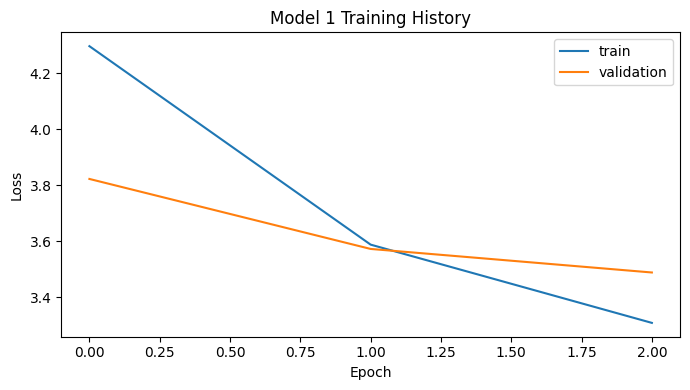

In [9]:
model1_history = train_model(model1, train_loader, val_loader, criterion, optimizer1, MODEL1_EPOCHS, "model1")
plot_training_history(model1_history, "Model 1 Training History", RESULTS_DIR / "model1_history.png")

In [10]:
checkpoint = torch.load(RESULTS_DIR / "model1_best.pt", map_location=device)
model1.load_state_dict(checkpoint["model_state_dict"])
model1_metrics, model1_predictions = evaluate_bleu(model1, test_eval_loader, idx2word)
print(model1_metrics)
save_json(model1_metrics, RESULTS_DIR / "model1_metrics.json")
model1_predictions.head()

{'BLEU-1': 0.5085299381517357, 'BLEU-2': 0.32295430126411734, 'BLEU-3': 0.19845236751460693, 'BLEU-4': 0.11898734185160385}


,image_id,file_name,prediction,references
0,26903,VizWiz_val_00003472.jpg,a white wall with a white <unk> on it,"[a ballpoint pen and a rubber band on a table,..."
1,29852,VizWiz_val_00006421.jpg,a white paper with a black and white label,[a label for paper that is resting on top of a...
2,28093,VizWiz_val_00004662.jpg,a white paper with a white label and a barcode,[cooking instructions on the back of a food pr...
3,24413,VizWiz_val_00000982.jpg,a computer screen with a math problem on it,[a script with printed words has some parts wr...
4,25490,VizWiz_val_00002059.jpg,a computer screen with a black background and ...,[the electronic display portion of a large dig...


## Model 1 Performance Summary

I use this table to summarize my first architecture for the Phase 2 group discussion.


In [11]:
model1_summary = pd.DataFrame([
    {"Metric": "Architecture", "Result": "ResNet50 encoder + LSTM decoder"},
    {"Metric": "Device used", "Result": str(device).upper()},
    {"Metric": "Epochs", "Result": MODEL1_EPOCHS},
    {"Metric": "Training time", "Result": format_duration(model1_history["total_training_seconds"])},
    {"Metric": "Final training loss", "Result": f"{model1_history['train_loss'][-1]:.4f}"},
    {"Metric": "Best validation loss", "Result": f"{min(model1_history['val_loss']):.4f}"},
    {"Metric": "BLEU-1", "Result": f"{model1_metrics['BLEU-1']:.4f}"},
    {"Metric": "BLEU-2", "Result": f"{model1_metrics['BLEU-2']:.4f}"},
    {"Metric": "BLEU-3", "Result": f"{model1_metrics['BLEU-3']:.4f}"},
    {"Metric": "BLEU-4", "Result": f"{model1_metrics['BLEU-4']:.4f}"},
])
model1_summary


,Metric,Result
0,Architecture,ResNet50 encoder + LSTM decoder
1,Device used,CUDA
2,Epochs,3
3,Training time,23.7 min
4,Final training loss,3.3079
5,Best validation loss,3.4880
6,BLEU-1,0.5085
7,BLEU-2,0.3230
8,BLEU-3,0.1985
9,BLEU-4,0.1190


## 7. Model 2: ResNet50 Encoder + LSTM Decoder + Attention

Model 2 keeps spatial ResNet50 features instead of compressing the image into one vector. The decoder learns attention weights over the 7 x 7 feature grid at each generated word.

In [12]:
class ResNetSpatialEncoder(nn.Module):
    def __init__(self, attention_dim=512, freeze=True):
        super().__init__()
        resnet = build_resnet50(weights=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.project = nn.Linear(2048, attention_dim)
        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, images):
        features = self.backbone(images)
        features = features.permute(0, 2, 3, 1).contiguous()
        features = features.view(features.size(0), -1, features.size(-1))
        return self.project(features)

class AdditiveAttention(nn.Module):
    def __init__(self, feature_dim, hidden_dim, attention_dim):
        super().__init__()
        self.feature_att = nn.Linear(feature_dim, attention_dim)
        self.hidden_att = nn.Linear(hidden_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden):
        scores = self.full_att(torch.tanh(self.feature_att(features) + self.hidden_att(hidden).unsqueeze(1))).squeeze(-1)
        alpha = torch.softmax(scores, dim=1)
        context = (features * alpha.unsqueeze(-1)).sum(dim=1)
        return context, alpha

class AttentionCaptioner(nn.Module):
    # Attention lets the decoder look at different spatial ResNet features for
    # each generated word instead of relying on one global image vector.
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, attention_dim=512, dropout=0.3, freeze_encoder=True):
        super().__init__()
        self.encoder = ResNetSpatialEncoder(attention_dim=attention_dim, freeze=freeze_encoder)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.attention = AdditiveAttention(attention_dim, hidden_dim, attention_dim)
        self.init_h = nn.Linear(attention_dim, hidden_dim)
        self.init_c = nn.Linear(attention_dim, hidden_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + attention_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def _init_hidden(self, features):
        mean_features = features.mean(dim=1)
        return torch.tanh(self.init_h(mean_features)), torch.tanh(self.init_c(mean_features))

    def forward(self, images, captions_input):
        features = self.encoder(images)
        embeddings = self.dropout(self.embedding(captions_input))
        h, c = self._init_hidden(features)
        logits = []
        for t in range(embeddings.size(1)):
            context, _ = self.attention(features, h)
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            logits.append(self.fc(self.dropout(h)))
        return torch.stack(logits, dim=1)

    @torch.no_grad()
    def generate_beam(self, image, beam_size=5, max_len=30, length_alpha=0.7):
        self.eval()
        if image.dim() == 3:
            image = image.unsqueeze(0)
        image = image.to(device)
        features = self.encoder(image)
        h, c = self._init_hidden(features)

        # Beam search keeps several likely partial captions instead of only the
        # single best next word. This improved Model 2 because attention has more
        # opportunity to recover from one weak word choice during decoding.
        beams = [([start_idx], 0.0, h, c, False)]
        for _ in range(max_len):
            candidates = []
            for seq, score, beam_h, beam_c, finished in beams:
                if finished:
                    candidates.append((seq, score, beam_h, beam_c, finished))
                    continue
                current = torch.tensor([seq[-1]], dtype=torch.long, device=device)
                emb = self.embedding(current).view(1, -1)
                context, _ = self.attention(features, beam_h)
                next_h, next_c = self.lstm_cell(torch.cat([emb, context], dim=1), (beam_h, beam_c))
                log_probs = torch.log_softmax(self.fc(next_h), dim=-1).squeeze(0)
                values, indices = torch.topk(log_probs, beam_size)
                for value, idx in zip(values.tolist(), indices.tolist()):
                    candidates.append((seq + [idx], score + value, next_h, next_c, idx == end_idx))

            def normalized_score(candidate):
                seq, score, _, _, _ = candidate
                length = max(1, len(seq) - 1)
                return score / (length ** length_alpha)

            beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]
            if all(item[4] for item in beams):
                break

        best_seq = max(beams, key=lambda item: item[1] / (max(1, len(item[0]) - 1) ** length_alpha))[0]
        return [idx for idx in best_seq[1:] if idx != end_idx]

    @torch.no_grad()
    def generate(self, image, max_len=30):
        return self.generate_beam(image, beam_size=MODEL2_BEAM_SIZE, max_len=max_len)

In [13]:
attention_train_loader = DataLoader(train_dataset, batch_size=ATTENTION_BATCH_SIZE, shuffle=True, collate_fn=collate_train, num_workers=NUM_WORKERS)
attention_val_loader = DataLoader(val_train_dataset, batch_size=ATTENTION_BATCH_SIZE, shuffle=False, collate_fn=collate_train, num_workers=NUM_WORKERS)
attention_test_eval_loader = DataLoader(test_eval_dataset, batch_size=ATTENTION_BATCH_SIZE, shuffle=False, collate_fn=collate_eval, num_workers=NUM_WORKERS)

model2 = AttentionCaptioner(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_encoder=True,
).to(device)

print(model2)
print("Trainable parameters:", f"{count_parameters(model2):,}")
optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=LEARNING_RATE)

AttentionCaptioner(
  (encoder): ResNetSpatialEncoder(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU

model2 epoch 1/5: train_loss=4.2324 val_loss=3.7859 time=9.0 min


model2 epoch 2/5: train_loss=3.5710 val_loss=3.5920 time=9.1 min


model2 epoch 3/5: train_loss=3.3070 val_loss=3.5221 time=9.0 min


model2 epoch 4/5: train_loss=3.1323 val_loss=3.4996 time=8.9 min


model2 epoch 5/5: train_loss=3.0011 val_loss=3.4991 time=8.9 min
model2 total training time: 45.0 min


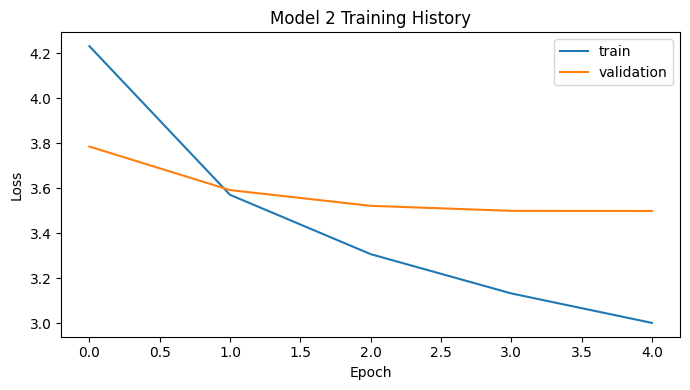

In [14]:
model2_history = train_model(model2, attention_train_loader, attention_val_loader, criterion, optimizer2, MODEL2_EPOCHS, "model2")
plot_training_history(model2_history, "Model 2 Training History", RESULTS_DIR / "model2_history.png")

In [15]:
checkpoint = torch.load(RESULTS_DIR / "model2_best.pt", map_location=device)
model2.load_state_dict(checkpoint["model_state_dict"])
model2_metrics, model2_predictions = evaluate_bleu(model2, attention_test_eval_loader, idx2word)
print(model2_metrics)
save_json(model2_metrics, RESULTS_DIR / "model2_metrics.json")
model2_predictions.head()

{'BLEU-1': 0.5669776447808484, 'BLEU-2': 0.3699181972085094, 'BLEU-3': 0.24248856616115005, 'BLEU-4': 0.1579803910924147}


image_id,file_name,prediction,references
26903,VizWiz_val_00003472.jpg,a white piece of paper with black writing on it,"['a ballpoint pen and a rubber band on a table', 'a pen and a rubber band sitting on a white surface', 'a gray plastic ballpoint writing pen and a rubber band', 'a white counter with an uncapped pen and rubber band']"
29852,VizWiz_val_00006421.jpg,a white piece of paper with black text on it,"['a label for paper that is resting on top of a brown couch', 'rolling papers that are laying open face down on brown upholstery', 'a pack of rolling paper sitting on a black background', 'a box on the floor with papers on it in black', 'a pack of rolling papers on top of a couch']"
28093,VizWiz_val_00004662.jpg,a close up of the back of a can of food,"['cooking instructions on the back of a food product', 'this appears to be some type of menu with black and red text']"
24413,VizWiz_val_00000982.jpg,a sheet of paper with questions on it,"['a script with printed words has some parts written with a red pen', 'a piece of paper with typing on it and a fold in the middle that has been corrected', 'a white piece of paper has red correction ink', ""a double spaced manuscript shows editor's marks in red ink"", 'a typed and printed essay with handwritten error checks']"
25490,VizWiz_val_00002059.jpg,a computer screen with a window open on it,"['the electronic display portion of a large digital clock program is seen', 'shows a clock with time and date and temperature', 'a close up of a digital clock showing the time 2100 hours', 'a digital display of date time and day', 'part numbers do not have a text on']"


## Model 2 Performance Summary

I use this table to summarize my refined architecture for the Phase 3 comparison.


In [32]:
model2_summary = pd.DataFrame([
    {"Metric": "Architecture", "Result": "ResNet50 spatial encoder + LSTM decoder"},
    {"Metric": "Attention", "Result": "Bahdanau-style additive attention"},
    {"Metric": "Decoding", "Result": f"Beam search, width {MODEL2_BEAM_SIZE}"},
    {"Metric": "Device used", "Result": str(device).upper()},
    {"Metric": "Epochs", "Result": MODEL2_EPOCHS},
    {"Metric": "Training time", "Result": format_duration(model2_history["total_training_seconds"])},
    {"Metric": "Final training loss", "Result": f"{model2_history['train_loss'][-1]:.4f}"},
    {"Metric": "Best validation loss", "Result": f"{min(model2_history['val_loss']):.4f}"},
    {"Metric": "BLEU-1", "Result": f"{model2_metrics['BLEU-1']:.4f}"},
    {"Metric": "BLEU-2", "Result": f"{model2_metrics['BLEU-2']:.4f}"},
    {"Metric": "BLEU-3", "Result": f"{model2_metrics['BLEU-3']:.4f}"},
    {"Metric": "BLEU-4", "Result": f"{model2_metrics['BLEU-4']:.4f}"},
])
model2_summary


Metric,Result
Architecture,ResNet50 spatial encoder + LSTM decoder
Attention,Bahdanau-style additive attention
Decoding,"Beam search, width 5"
Device used,CUDA
Epochs,5
Training time,45.0 min
Final training loss,3.0011
Best validation loss,3.4991
BLEU-1,0.5670
BLEU-2,0.3699


## 8. Model Comparison

In [16]:
comparison = pd.DataFrame([
    {
        "Model": "Model 1",
        "Encoder": "ResNet50 global feature",
        "Decoder": "LSTM",
        "Attention": "No",
        "Train loss": model1_history["train_loss"][-1],
        "Validation loss": min(model1_history["val_loss"]),
        "Training time": format_duration(model1_history["total_training_seconds"]),
        **model1_metrics,
        "Comments": "My baseline model uses a single image representation.",
    },
    {
        "Model": "Model 2",
        "Encoder": "ResNet50 spatial features",
        "Decoder": "LSTMCell",
        "Attention": "Bahdanau-style additive attention",
        "Train loss": model2_history["train_loss"][-1],
        "Validation loss": min(model2_history["val_loss"]),
        "Training time": format_duration(model2_history["total_training_seconds"]),
        **model2_metrics,
        "Comments": "My refined model uses attention over spatial image regions.",
    },
])
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
comparison

Model,Encoder,Decoder,Attention,Decoding,Train loss,Validation loss,Training time,BLEU-1,BLEU-2,BLEU-3,BLEU-4,Comments
Model 1,ResNet50 global feature,LSTM,No,Greedy,3.307884,3.487972,23.7 min,0.508530,0.322954,0.198452,0.118987,My baseline model uses a single image representation.
Model 2,ResNet50 spatial features,LSTMCell,Bahdanau-style additive attention,"Beam search, width 5",3.001141,3.499135,45.0 min,0.566978,0.369918,0.242489,0.157980,My refined model uses attention plus beam search decoding.


## 9. Visual Inspection

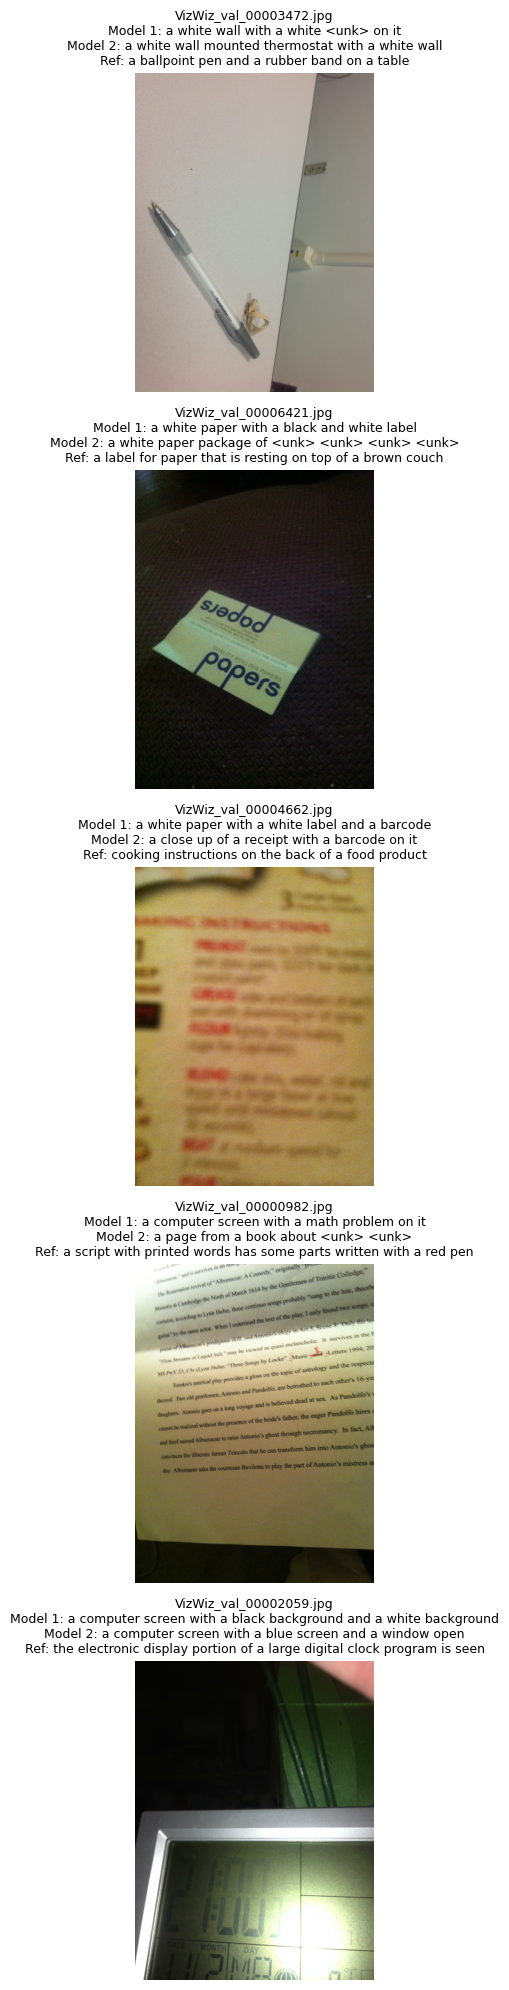

image_id,file_name,reference_captions,model1_caption,model2_caption
26903,VizWiz_val_00003472.jpg,"['a ballpoint pen and a rubber band on a table', 'a pen and a rubber band sitting on a white surface', 'a gray plastic ballpoint writing pen and a rubber band', 'a white counter with an uncapped pen and rubber band']",a white wall with a white <unk> on it,a white piece of paper with black writing on it
29852,VizWiz_val_00006421.jpg,"['a label for paper that is resting on top of a brown couch', 'rolling papers that are laying open face down on brown upholstery', 'a pack of rolling paper sitting on a black background', 'a box on the floor with papers on it in black', 'a pack of rolling papers on top of a couch']",a white paper with a black and white label,a white piece of paper with black text on it
28093,VizWiz_val_00004662.jpg,"['cooking instructions on the back of a food product', 'this appears to be some type of menu with black and red text']",a white paper with a white label and a barcode,a close up of the back of a can of food
24413,VizWiz_val_00000982.jpg,"['a script with printed words has some parts written with a red pen', 'a piece of paper with typing on it and a fold in the middle that has been corrected', 'a white piece of paper has red correction ink', ""a double spaced manuscript shows editor's marks in red ink"", 'a typed and printed essay with handwritten error checks']",a computer screen with a math problem on it,a sheet of paper with questions on it
25490,VizWiz_val_00002059.jpg,"['the electronic display portion of a large digital clock program is seen', 'shows a clock with time and date and temperature', 'a close up of a digital clock showing the time 2100 hours', 'a digital display of date time and day', 'part numbers do not have a text on']",a computer screen with a black background and a white background,a computer screen with a window open on it


In [17]:
sample_predictions = []
sample_count = min(5, len(test_eval_dataset))
fig, axes = plt.subplots(sample_count, 1, figsize=(8, 4 * sample_count))
if sample_count == 1:
    axes = [axes]

for ax, idx in zip(axes, range(sample_count)):
    item = test_eval_dataset[idx]
    image = Image.open(item["image_path"]).convert("RGB")
    model1_caption = decode_caption(model1.generate(item["image"]), idx2word)
    model2_caption = decode_caption(model2.generate(item["image"]), idx2word)
    refs = [" ".join(ref) for ref in item["references"]]
    sample_predictions.append({
        "image_id": item["image_id"],
        "file_name": item["file_name"],
        "reference_captions": refs,
        "model1_caption": model1_caption,
        "model2_caption": model2_caption,
    })
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{item['file_name']}\nModel 1: {model1_caption}\nModel 2: {model2_caption}\nRef: {refs[0]}",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

sample_predictions_df = pd.DataFrame(sample_predictions)
sample_predictions_df.to_csv(RESULTS_DIR / "sample_predictions.csv", index=False)
sample_predictions_df